# Customer Churn Analysis & Customer Intelligence

End-to-end churn analysis: data cleaning, feature engineering, KPI reporting and visualization for a subscription-based business.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings("ignore")

# consistent, clean visual theme for all charts
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.edgecolor'] = '#333333'

PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

## 2. Import Data

In [2]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
    SELECT name FROM sqlite_master WHERE type='table';
"""
tables = pd.read_sql(sql_query, conn)

for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Loaded: df_{table_name} -> {df.shape}")

conn.close()

Loaded: df_db_customer -> (1200, 8)
Loaded: df_db_subscription -> (1200, 11)
Loaded: df_db_support -> (574, 6)


In [3]:
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable: {table_name}")
    columns = pd.read_sql(f"PRAGMA table_info({table_name});", conn)
    print(columns['name'].tolist())

conn.close()


Table: db_customer
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table: db_subscription
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table: db_support
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


## 3. Data Cleaning

### 3.1 Customer table

In [4]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,1825-AHFTR,Mira,India,Delhi,Male,1974-10-23 00:00:00,job,None
1,7360-PVAUS,aryan,India,Uttar Pradesh,Male,1982-01-16 00:00:00,movie,None
2,6202-CHQXJ,aditya,NaN,Delhi,Female,1968-07-31 00:00:00,job,None
3,4375-SRBQN,suresh,India,Meghalaya,Male,1979-07-20 00:00:00,travel,None
4,7518-DDTOT,vishakha,India,Madhya Pradesh,Female,1969-01-29 00:00:00,travel,None


In [5]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  1200 non-null   str   
 1   name        1200 non-null   str   
 2   country     1141 non-null   str   
 3   state       1200 non-null   str   
 4   gender      1200 non-null   str   
 5   dob         1200 non-null   str   
 6   interests   852 non-null    str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 75.1+ KB


**Rename column**

In [6]:
df_db_customer.rename(columns={'name': 'customer_name'}, inplace=True)

**Drop unused columns**

In [7]:
df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)

In [8]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerid     1200 non-null   str  
 1   customer_name  1200 non-null   str  
 2   country        1141 non-null   str  
 3   state          1200 non-null   str  
 4   gender         1200 non-null   str  
 5   dob            1200 non-null   str  
dtypes: str(6)
memory usage: 56.4 KB


**Fix data type - dob**

In [9]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

**Standardize gender labels**

In [10]:
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female', 'Women', 'Men']
Length: 4, dtype: str

In [11]:
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men': 'Male', 'Women': 'Female'})

In [12]:
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

**Fix missing country using state**

In [13]:
df_db_customer[df_db_customer['country'].isna()].shape[0]

59

In [14]:
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [15]:
df_db_customer['country'].isna().sum()

np.int64(0)

### 3.2 Subscription table

In [16]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,1825-AHFTR,2023-09-01,Organic,2024-08-31,Premium,Annual,NaN,NaN,18.21,674,11
1,7360-PVAUS,2022-01-10,Paid,2023-01-10,Basic,Annual,NaN,NaN,7.72,428,37
2,6202-CHQXJ,2019-02-18,Paid,2020-11-09,Standard,Monthly,NaN,NaN,11.67,945,21
3,4375-SRBQN,2020-07-27,Refferal,2021-08-21,Basic,Monthly,2021-11-01,Technical issues,8.62,121,67
4,7518-DDTOT,2019-03-26,Refferal,2022-03-25,Basic,Annual,NaN,NaN,7.82,604,24


In [17]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               1200 non-null   str    
 1   subscription_start_date  1200 non-null   str    
 2   subscription_type        1200 non-null   str    
 3   renewal_date             1200 non-null   str    
 4   plan_type                1200 non-null   str    
 5   contract_type            1200 non-null   str    
 6   cancellation_date        387 non-null    str    
 7   cancellation_reason      387 non-null    str    
 8   monthly_charges          1200 non-null   float64
 9   cltv                     1200 non-null   int64  
 10  churn_score              1200 non-null   int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 103.3 KB


**Fix date columns**

In [18]:
date_cols = ['subscription_start_date', 'renewal_date', 'cancellation_date']
df_db_subscription[date_cols] = df_db_subscription[date_cols].apply(pd.to_datetime)

In [19]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               1200 non-null   str           
 1   subscription_start_date  1200 non-null   datetime64[us]
 2   subscription_type        1200 non-null   str           
 3   renewal_date             1200 non-null   datetime64[us]
 4   plan_type                1200 non-null   str           
 5   contract_type            1200 non-null   str           
 6   cancellation_date        387 non-null    datetime64[us]
 7   cancellation_reason      387 non-null    str           
 8   monthly_charges          1200 non-null   float64       
 9   cltv                     1200 non-null   int64         
 10  churn_score              1200 non-null   int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 103.3 KB


### 3.3 Support table

In [20]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,7669-NZWAS,2024-10-05 00:00:00,N,100,None,NaN
1,7669-NZWAS,2026-07-03 00:00:00,Y,42,None,billing query
2,7669-NZWAS,2023-12-12 00:00:00,N,59,None,slow response
3,2647-OUNAI,2025-01-17 00:00:00,N,60,None,guidance to renew
4,2647-OUNAI,2021-11-08 00:00:00,N,69,None,NaN


In [21]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 574 entries, 0 to 573
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      574 non-null    str   
 1   complaint_date  574 non-null    str   
 2   escalations     574 non-null    str   
 3   csat_score      574 non-null    int64 
 4   col_1           0 non-null      object
 5   comment         388 non-null    str   
dtypes: int64(1), object(1), str(4)
memory usage: 27.0+ KB


**Drop unused columns**

In [22]:
df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

**Fix date column**

In [23]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [24]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 574 entries, 0 to 573
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      574 non-null    str           
 1   complaint_date  574 non-null    datetime64[us]
 2   escalations     574 non-null    str           
 3   csat_score      574 non-null    int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 18.1 KB


## 4. Feature Engineering

**Create churn flag** — a customer is churned if a cancellation date exists

In [25]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,1825-AHFTR,2023-09-01,Organic,2024-08-31,Premium,Annual,NaT,NaN,18.21,674,11,0
1,7360-PVAUS,2022-01-10,Paid,2023-01-10,Basic,Annual,NaT,NaN,7.72,428,37,0
2,6202-CHQXJ,2019-02-18,Paid,2020-11-09,Standard,Monthly,NaT,NaN,11.67,945,21,0
3,4375-SRBQN,2020-07-27,Refferal,2021-08-21,Basic,Monthly,2021-11-01,Technical issues,8.62,121,67,1
4,7518-DDTOT,2019-03-26,Refferal,2022-03-25,Basic,Annual,NaT,NaN,7.82,604,24,0


**Consolidate support tickets per customer**

In [26]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [27]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep='last')

**Merge into a single analysis-ready dataframe**

In [28]:
df = (df_db_subscription
      .merge(df_db_customer, on='customerid', how='left')
      .merge(df_db_support, on='customerid', how='left'))

In [29]:
df.shape

(1200, 21)

**Export**

In [30]:
df.to_csv('exported_churn_data.csv', index=False)

## 5. Key Metrics

In [31]:
churn_rate = df['churn_flag'].mean() * 100
retention_rate = 100 - churn_rate

print("Churn Rate     :", round(churn_rate, 2), "%")
print("Retention Rate :", round(retention_rate, 2), "%")

Churn Rate     : 32.25 %
Retention Rate : 67.75 %


In [32]:
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2)
                 .reset_index(name='churn_rate_pct'))
churn_by_plan

,plan_type,churn_rate_pct
0,Basic,38.37
1,Premium,24.04
2,Standard,31.85


In [33]:
churn_by_contract = (df.groupby('contract_type')['churn_flag'].mean().mul(100).round(2)
                     .reset_index(name='churn_rate_pct'))
churn_by_contract

,contract_type,churn_rate_pct
0,Annual,23.56
1,Monthly,39.75


In [34]:
arpu = df['monthly_charges'].mean()
print("ARPU (Avg Revenue Per User) =", round(arpu, 2))

ARPU (Avg Revenue Per User) = 13.13


In [35]:
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) =", round(avg_tenure))

Avg Tenure (Days) = 1548


In [36]:
revenue_at_risk = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
print("Monthly Revenue at Risk =", round(revenue_at_risk, 2))

Monthly Revenue at Risk = 4739.98


In [37]:
escalation_rate = (df['escalations'] == 'Y').mean() * 100
print("Escalation Rate =", round(escalation_rate, 2), "%")

Escalation Rate = 6.42 %


In [38]:
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Complaints Per User =", round(avg_complaints, 2))

Avg Complaints Per User = 0.48


In [39]:
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0)
correlation = df[['escalations', 'churn_flag']].dropna()['escalations'].corr(df['churn_flag'])
print("Correlation (Escalation vs Churn) =", round(correlation, 2))

Correlation (Escalation vs Churn) = 0.12


**Churn risk bucket**

In [40]:
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]
choices = ['low', 'med', 'high']
df['churn_risk'] = np.select(conditions, choices, default='unknown')

df['churn_risk'].value_counts()

churn_risk
low     707
med     258
high    235
Name: count, dtype: int64

**High-value customers at risk**

In [41]:
high_value_at_risk = df[(df['churn_risk'] == 'high') & (df['cltv'] > df['cltv'].median())]

n_at_risk = high_value_at_risk['customerid'].nunique()
revenue_exposure = high_value_at_risk['monthly_charges'].sum()

print("High-Value Customers at High Risk :", n_at_risk)
print("Monthly Revenue Exposure          :", round(revenue_exposure, 2))

High-Value Customers at High Risk : 25
Monthly Revenue Exposure          : 489.17


## 6. Visualizations

In [42]:
df_visual = df.copy()

**Monthly churn trend**

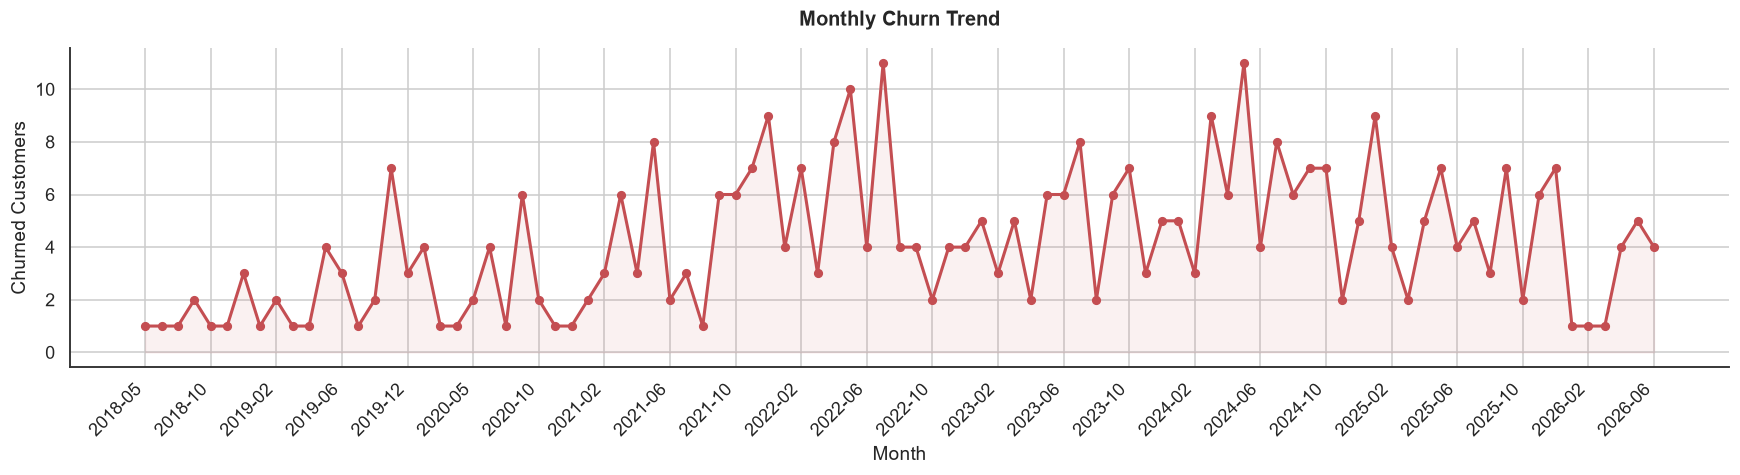

In [43]:
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')
churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

x_labels = churn_trend.index.astype(str)

plt.figure(figsize=(16, 4.5))
plt.plot(range(len(churn_trend)), churn_trend.values, color='#C44E52', marker='o',
         linewidth=2, markersize=5)
plt.fill_between(range(len(churn_trend)), churn_trend.values, color='#C44E52', alpha=0.08)
plt.title('Monthly Churn Trend', pad=15)
plt.xlabel('Month')
plt.ylabel('Churned Customers')

tick_positions = range(0, len(x_labels), 4)
plt.xticks(tick_positions, [x_labels[i] for i in tick_positions], rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

**Churn rate by plan type**

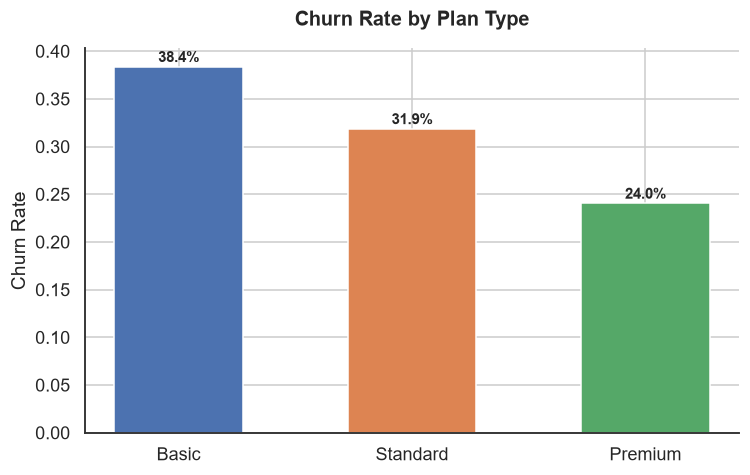

In [44]:
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean().reindex(['Basic', 'Standard', 'Premium'])

plt.figure(figsize=(7, 4.5))
bars = plt.bar(churn_plan.index, churn_plan.values, color=PALETTE[:3], width=0.55)
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
              f'{b.get_height()*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.title('Churn Rate by Plan Type', pad=15)
plt.xlabel('')
plt.ylabel('Churn Rate')
sns.despine()
plt.tight_layout()
plt.show()

**Churn rate by state**

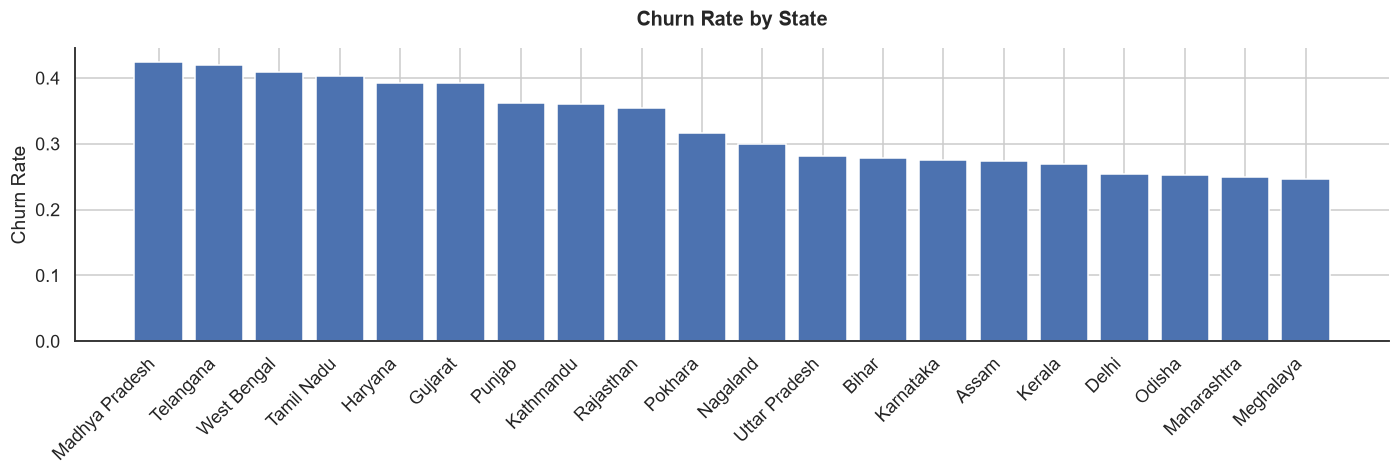

In [45]:
churn_state = df_visual.groupby('state')['churn_flag'].mean().sort_values(ascending=False)

plt.figure(figsize=(13, 4.5))
plt.bar(churn_state.index, churn_state.values, color='#4C72B0')
plt.title('Churn Rate by State', pad=15)
plt.xlabel('')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

**Correlation heatmap**

In [46]:
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].copy()

order_mappings = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

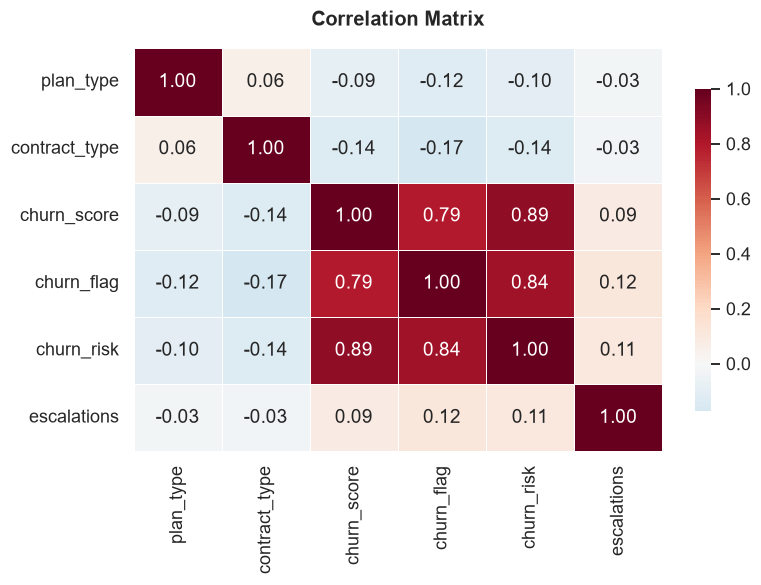

In [47]:
plt.figure(figsize=(7.5, 5.5))
sns.heatmap(df_encoded.corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix', pad=15)
plt.tight_layout()
plt.show()

**Plan vs monthly charges, split by gender and churn risk**

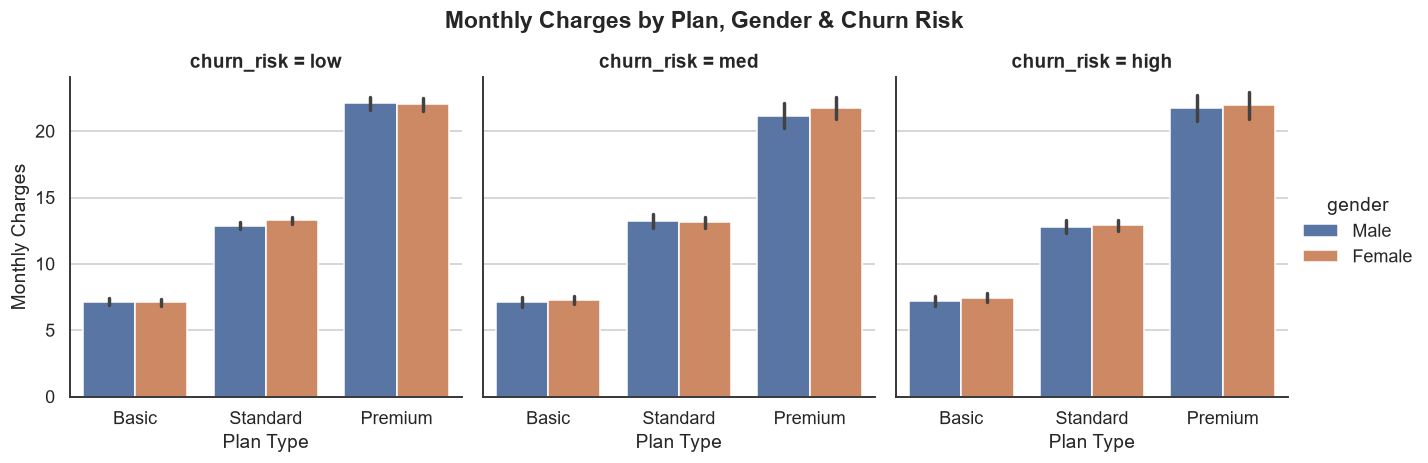

In [48]:
g = sns.catplot(data=df_visual, x='plan_type', y='monthly_charges', hue='gender',
                 col='churn_risk', kind='bar', height=4, palette=['#4C72B0', '#DD8452'],
                 order=['Basic', 'Standard', 'Premium'], col_order=['low', 'med', 'high'])
g.figure.suptitle('Monthly Charges by Plan, Gender & Churn Risk', y=1.05, fontweight='bold')
g.set_axis_labels('Plan Type', 'Monthly Charges')
plt.show()

### Executive Summary Dashboard

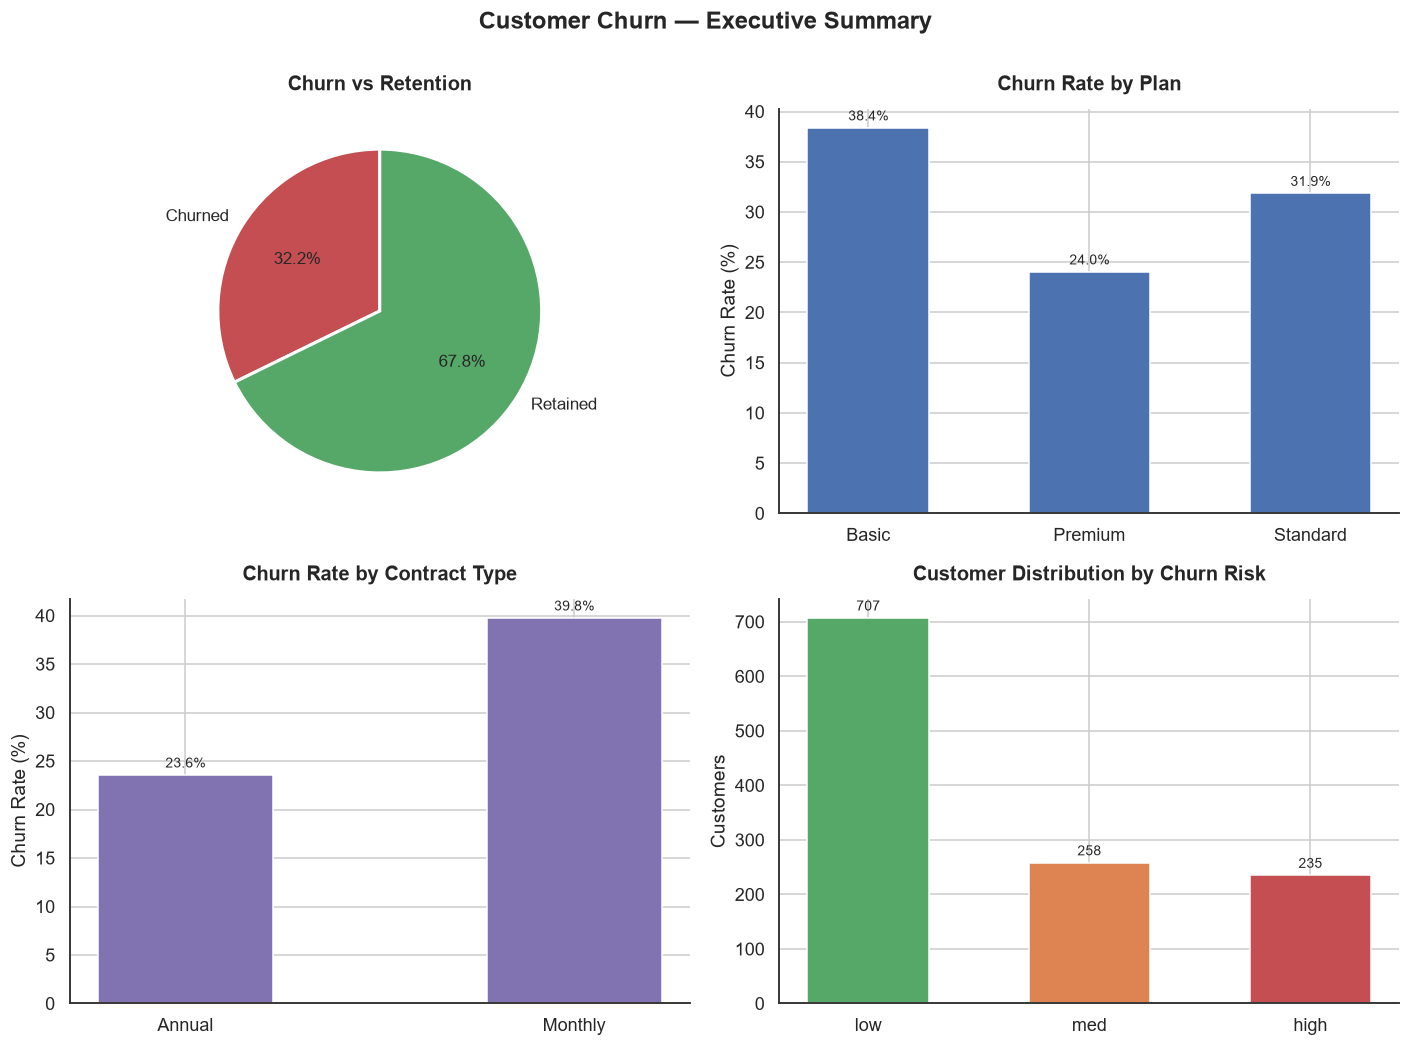

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))
fig.patch.set_facecolor('white')

# churn vs retention
axes[0, 0].pie([churn_rate, retention_rate], labels=['Churned', 'Retained'],
               autopct='%1.1f%%', colors=['#C44E52', '#55A868'], startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 2},
               textprops={'fontsize': 11})
axes[0, 0].set_title('Churn vs Retention', pad=12)

# churn rate by plan
bars1 = axes[0, 1].bar(churn_by_plan['plan_type'], churn_by_plan['churn_rate_pct'], color='#4C72B0', width=0.55)
axes[0, 1].bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=9)
axes[0, 1].set_title('Churn Rate by Plan', pad=12)
axes[0, 1].set_ylabel('Churn Rate (%)')
axes[0, 1].spines[['top', 'right']].set_visible(False)

# churn rate by contract
bars2 = axes[1, 0].bar(churn_by_contract['contract_type'], churn_by_contract['churn_rate_pct'], color='#8172B2', width=0.45)
axes[1, 0].bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=9)
axes[1, 0].set_title('Churn Rate by Contract Type', pad=12)
axes[1, 0].set_ylabel('Churn Rate (%)')
axes[1, 0].spines[['top', 'right']].set_visible(False)

# churn risk distribution
risk_counts = df['churn_risk'].value_counts().reindex(['low', 'med', 'high'])
bars3 = axes[1, 1].bar(risk_counts.index, risk_counts.values, color=['#55A868', '#DD8452', '#C44E52'], width=0.55)
axes[1, 1].bar_label(bars3, padding=3, fontsize=9)
axes[1, 1].set_title('Customer Distribution by Churn Risk', pad=12)
axes[1, 1].set_ylabel('Customers')
axes[1, 1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Customer Churn — Executive Summary', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

## 8. Churn Prediction Model

A simple Logistic Regression model to predict churn from customer, plan and support behavior — using only pre-cancellation signals (no leakage from churn_score / churn_risk, which are themselves churn-derived).

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Prepare features**

In [51]:
model_df = df_visual[['plan_type', 'contract_type', 'gender', 'monthly_charges',
                       'cltv', 'tenure_days', 'escalations', 'complaint_count', 'churn_flag']].copy()

model_df['complaint_count'] = model_df['complaint_count'].fillna(0)
model_df = pd.get_dummies(model_df, columns=['plan_type', 'contract_type', 'gender'], drop_first=True)

X = model_df.drop(columns='churn_flag')
y = model_df['churn_flag']
X.head()

,monthly_charges,cltv,tenure_days,escalations,complaint_count,plan_type_Premium,plan_type_Standard,contract_type_Monthly,gender_Male
0,18.21,674,1050.0,0,0.0,True,False,False,True
1,7.72,428,1649.0,0,0.0,False,False,False,True
2,11.67,945,2706.0,0,0.0,False,True,True,False
3,8.62,121,462.0,0,0.0,False,False,True,True
4,7.82,604,2670.0,0,0.0,False,False,False,False


**Train / test split and scaling**

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 960 | Test size: 240


**Train the model**

In [53]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy =", round(accuracy * 100, 2), "%")

Accuracy = 87.08 %


**Classification report**

In [54]:
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

              precision    recall  f1-score   support

    Retained       0.89      0.93      0.91       163
     Churned       0.83      0.75      0.79        77

    accuracy                           0.87       240
   macro avg       0.86      0.84      0.85       240
weighted avg       0.87      0.87      0.87       240



**Confusion matrix**

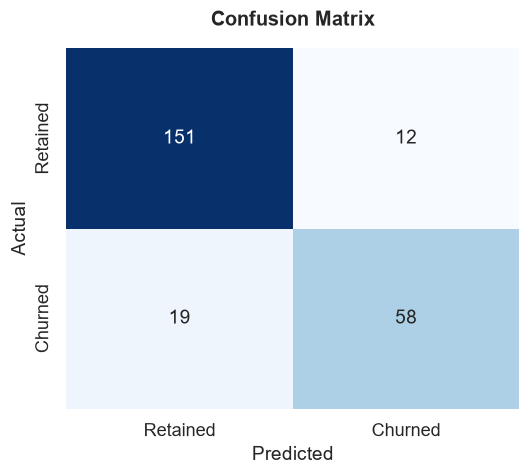

In [55]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
plt.title('Confusion Matrix', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

**Feature importance (model coefficients)**

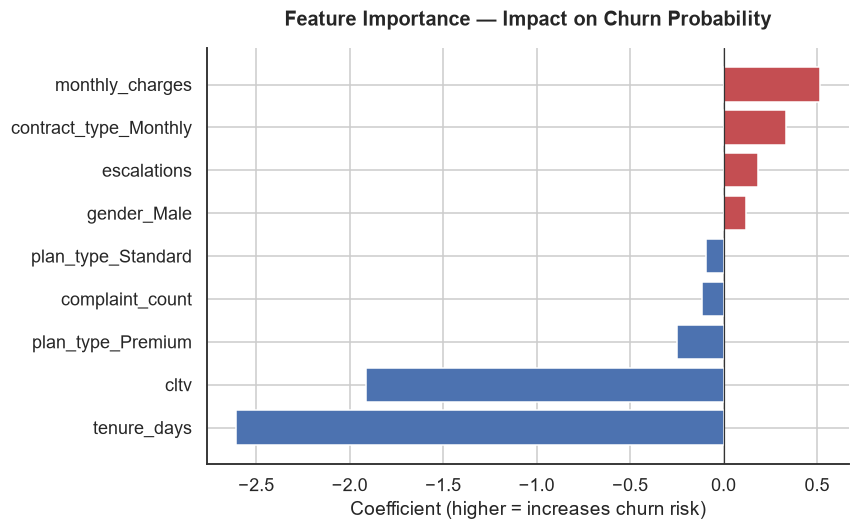

In [56]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient')

colors = ['#C44E52' if c > 0 else '#4C72B0' for c in coef_df['coefficient']]

plt.figure(figsize=(8, 5))
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='#333333', linewidth=0.8)
plt.title('Feature Importance — Impact on Churn Probability', pad=15)
plt.xlabel('Coefficient (higher = increases churn risk)')
sns.despine()
plt.tight_layout()
plt.show()

## 7. Pivot Tables

In [57]:
pd.pivot_table(df_visual, index='plan_type', values='churn_flag', aggfunc='mean')

,churn_flag
plan_type,
Basic,0.383693
Premium,0.240418
Standard,0.318548


In [58]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc={
        'monthly_charges': 'sum',
        'customerid': 'nunique',
        'churn_flag': 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.383693,417,2999.75
Premium,0.240418,287,6289.28
Standard,0.318548,496,6464.48
